# **Analisis dan Prediksi Harga Properti untuk Mendukung Keputusan Pembelian Rumah bagi First-Time Home Buyer**

**STUDY CASE 6 - HOUSING PRICE PREDICTION**

**SAINS DATA PADA INDUSTRI**

Kelompok 7
1. Justin Jeremia - 103052330106
2. Annisa Azzahra Rahmah - 103052300056
3. Eliezer Sharon Hutabarat - 103052300090
4. Amalia Ananda Putri - 103052330078

DS - 47 - 01


---






# **1. Import Library**

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# **2. Load Dataset**

In [ ]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# **3. Dataset Information**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# **4. Descriptive Statistics**

In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


# **5. Missing Value Check**

In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


# **6. Duplicate Check**

In [ ]:
df.duplicated().sum()

np.int64(0)

# **7. EDA**



## **7.1 Distribusi Harga Rumah**

**Tujuan Analisis** : Menganalisis sebaran harga rumah pada dataset untuk memahami karakteristik pasar perumahan dan rentang harga yang paling umum tersedia bagi first-time home buyer.

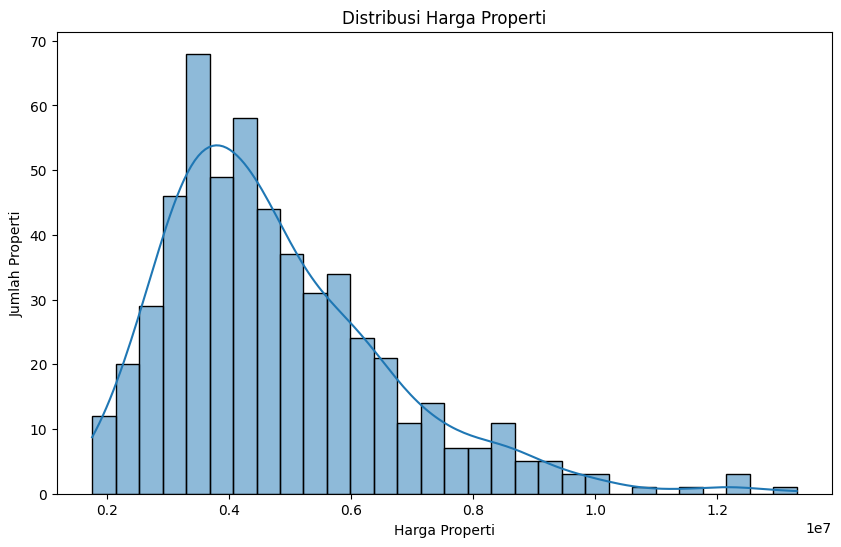

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='price',
    bins=30,
    kde=True
)

plt.title('Distribusi Harga Properti')
plt.xlabel('Harga Properti')
plt.ylabel('Jumlah Properti')

plt.show()

In [ ]:
print(f"Rata-rata harga properti : {df['price'].mean():,.0f}")
print(f"Median harga properti    : {df['price'].median():,.0f}")
print(f"Harga minimum properti   : {df['price'].min():,.0f}")
print(f"Harga maksimum properti  : {df['price'].max():,.0f}")

Rata-rata harga properti : 4,766,729
Median harga properti    : 4,340,000
Harga minimum properti   : 1,750,000
Harga maksimum properti  : 13,300,000


**Analisis :**

Berdasarkan distribusi harga properti, sebagian besar rumah berada pada rentang harga menengah dengan puncak distribusi berada di sekitar harga 3–5 juta. Distribusi data menunjukkan pola right-skewed (miring ke kanan), yang mengindikasikan bahwa jumlah rumah dengan harga tinggi relatif lebih sedikit dibandingkan rumah dengan harga menengah.

Selain itu, nilai rata-rata harga properti sebesar 4.766.729, sedangkan nilai median sebesar 4.340.000. Rata-rata yang lebih tinggi dibandingkan median menunjukkan adanya beberapa properti dengan harga sangat tinggi yang meningkatkan nilai rata-rata secara keseluruhan.

Harga properti pada dataset memiliki rentang yang cukup lebar, mulai dari 1.750.000 hingga 13.300.000, yang menunjukkan adanya variasi harga yang signifikan di pasar perumahan.


**Insight** **Bisnis :**

Pasar perumahan pada dataset lebih didominasi oleh rumah dengan harga menengah dibandingkan rumah premium. Kondisi ini menunjukkan bahwa sebagian besar pilihan properti berada pada segmen yang relatif lebih terjangkau.

Bagi first-time home buyer, informasi ini dapat digunakan untuk memahami ekspektasi harga pasar dan menentukan anggaran yang lebih realistis sebelum melakukan pembelian rumah. Selain itu, keberadaan sejumlah kecil rumah dengan harga sangat tinggi mengindikasikan adanya segmen premium yang kemungkinan hanya dapat dijangkau oleh kelompok pembeli tertentu.

## **7.2 Analisis Pengaruh Luas Properti terhadap Harga Properti**

**Tujuan Analisis** : Menganalisis hubungan antara luas properti dan harga rumah untuk mengetahui apakah peningkatan luas bangunan berpengaruh terhadap kenaikan harga properti.

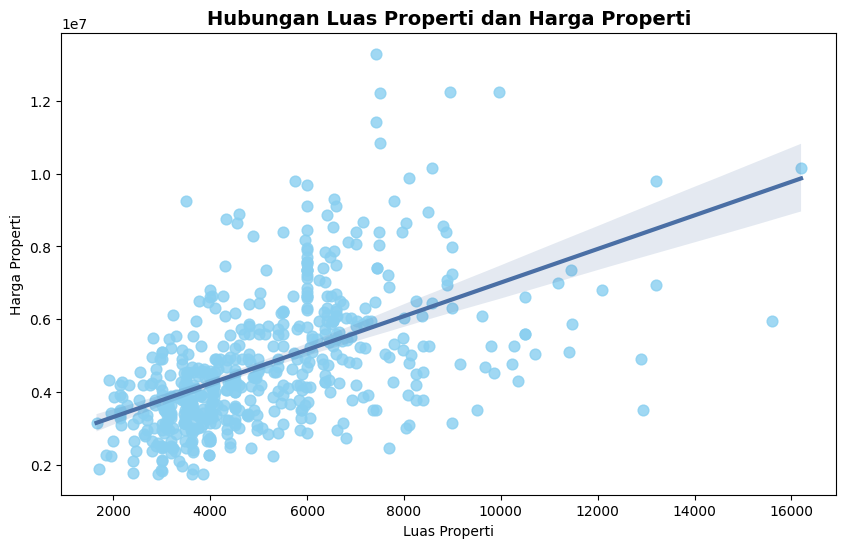

In [ ]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='area',
    y='price',
    scatter_kws={
        'color':'#89CFF0',
        'alpha':0.8,
        's':60
    },
    line_kws={
        'color':'#4A6FA5',
        'linewidth':3
    }
)

plt.title('Hubungan Luas Properti dan Harga Properti', fontsize=14, fontweight='bold')
plt.xlabel('Luas Properti')
plt.ylabel('Harga Properti')

plt.show()

**Analisis :**

Berdasarkan visualisasi di atas, terlihat adanya hubungan positif antara luas properti dan harga properti. Hal ini ditunjukkan oleh garis tren yang cenderung meningkat, yang mengindikasikan bahwa semakin besar luas properti, maka harga rumah cenderung semakin tinggi.

Meskipun demikian, penyebaran titik data yang cukup luas menunjukkan bahwa properti dengan luas yang sama dapat memiliki harga yang berbeda. Kondisi ini mengindikasikan bahwa harga rumah tidak hanya dipengaruhi oleh luas properti, tetapi juga oleh faktor lain seperti lokasi, fasilitas rumah, akses jalan utama, dan status furnishing.

Selain itu, terdapat beberapa properti dengan luas yang sangat besar dan harga yang jauh lebih tinggi dibandingkan mayoritas rumah lainnya. Hal ini menunjukkan adanya segmen properti premium dalam pasar perumahan.

**Insight Bisnis :**

Luas properti merupakan salah satu faktor utama yang memengaruhi harga rumah. Bagi first-time home buyer, peningkatan luas rumah biasanya akan diikuti oleh kenaikan harga yang cukup signifikan.

Temuan ini menunjukkan bahwa calon pembeli perlu mempertimbangkan kebutuhan ruang secara cermat. Memilih rumah dengan luas yang lebih besar memang memberikan kenyamanan tambahan, namun juga berpotensi meningkatkan biaya pembelian secara signifikan. Oleh karena itu, first-time home buyer perlu mencari keseimbangan antara kebutuhan ruang dan kemampuan finansial agar memperoleh properti yang memberikan nilai terbaik sesuai anggaran yang dimiliki.

## **7.3 Analisis Harga Properti Berdasarkan Status Furnishing**

**Tujuan Analisis** : Menganalisis pengaruh status furnishing terhadap harga properti untuk memahami apakah rumah yang telah dilengkapi furnitur memiliki nilai jual yang lebih tinggi dibandingkan rumah semi-furnished atau unfurnished.

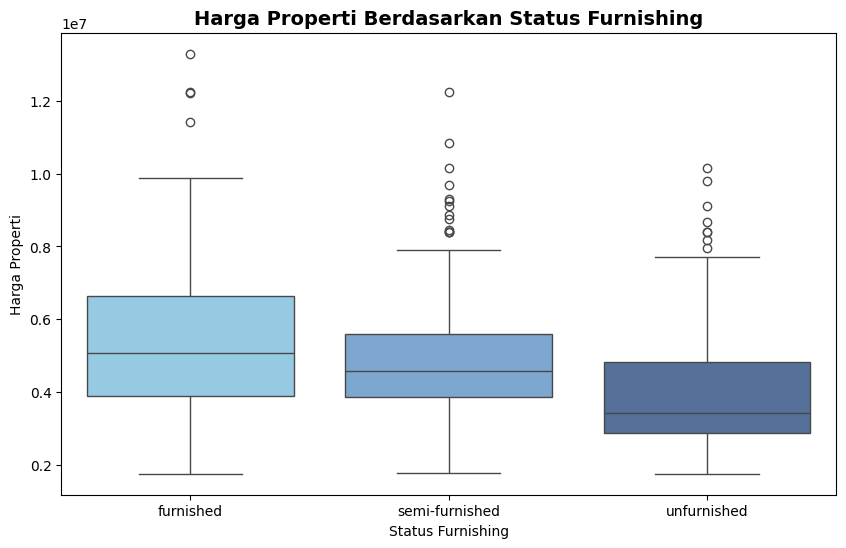

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='furnishingstatus',
    y='price',
    palette=['#89CFF0','#6FA8DC','#4A6FA5']
)

plt.title('Harga Properti Berdasarkan Status Furnishing',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Status Furnishing')
plt.ylabel('Harga Properti')

plt.show()

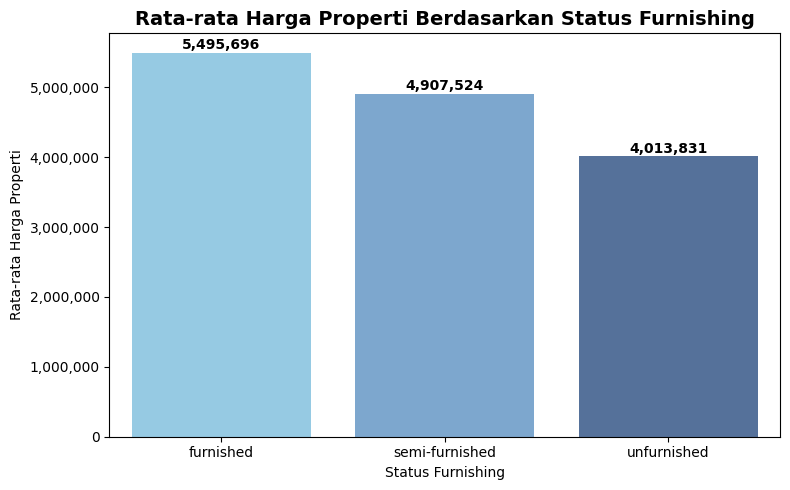

In [ ]:
import matplotlib.ticker as ticker

avg_price = df.groupby('furnishingstatus')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette=['#89CFF0','#6FA8DC','#4A6FA5']
)

for i, value in enumerate(avg_price.values):
    ax.text(
        i,
        value + 50000,
        f'{value:,.0f}',
        ha='center',
        fontweight='bold'
    )

ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

plt.title('Rata-rata Harga Properti Berdasarkan Status Furnishing',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Status Furnishing')
plt.ylabel('Rata-rata Harga Properti')

plt.tight_layout()
plt.show()

In [ ]:
avg_price = df.groupby('furnishingstatus')['price'].mean().sort_values(ascending=False)

for status, price in avg_price.items():
    print(f"{status}: {price:,.0f}")

furnished: 5,495,696
semi-furnished: 4,907,524
unfurnished: 4,013,831


**Analisis :**

Berdasarkan visualisasi boxplot, terdapat perbedaan harga properti yang cukup jelas pada setiap kategori status furnishing. Properti dengan status furnished memiliki median harga tertinggi dibandingkan kategori lainnya, diikuti oleh semi-furnished dan unfurnished.

Hasil perhitungan rata-rata harga juga menunjukkan pola yang sama. Properti furnished memiliki rata-rata harga sebesar 5.495.696, lebih tinggi dibandingkan semi-furnished sebesar 4.907.524 dan unfurnished sebesar 4.013.831.

Temuan ini menunjukkan bahwa kelengkapan furnitur merupakan salah satu faktor yang berkontribusi terhadap peningkatan nilai jual properti. Selain itu, terdapat beberapa properti dengan harga yang sangat tinggi pada setiap kategori, yang mengindikasikan keberadaan segmen pasar premium.

**Insight Bisnis :**

Status furnishing menjadi salah satu faktor yang perlu dipertimbangkan oleh first-time home buyer dalam menentukan pilihan rumah. Properti furnished menawarkan kemudahan karena dapat langsung ditempati tanpa memerlukan biaya tambahan untuk pembelian furnitur. Namun, kemudahan tersebut diikuti oleh harga properti yang lebih tinggi.

Sebaliknya, properti unfurnished memiliki harga yang relatif lebih rendah sehingga dapat menjadi alternatif bagi first-time home buyer yang memiliki keterbatasan anggaran dan bersedia melengkapi furnitur secara bertahap sesuai kebutuhan. Oleh karena itu, keputusan memilih rumah furnished atau unfurnished perlu disesuaikan dengan kondisi finansial serta prioritas masing-masing pembeli.

## **7.4 Analisis Harga Properti Berdasarkan Preferred Area**

**Tujuan Analisis** : Menganalisis perbedaan harga properti berdasarkan status preferred area untuk mengetahui pengaruh lokasi terhadap harga rumah.

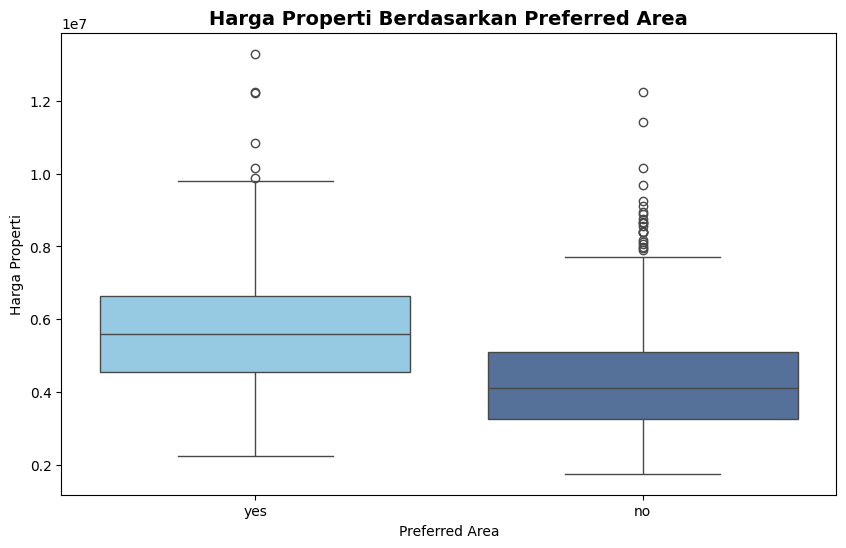

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='prefarea',
    y='price',
    palette=['#89CFF0','#4A6FA5']
)

plt.title('Harga Properti Berdasarkan Preferred Area',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Preferred Area')
plt.ylabel('Harga Properti')

plt.show()

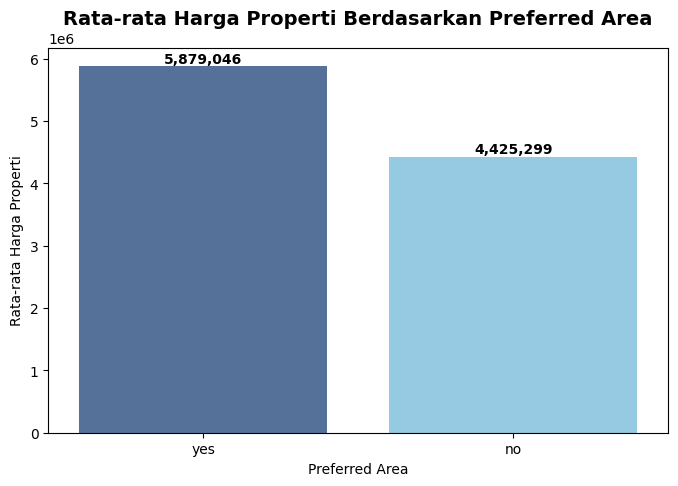

In [ ]:
avg_price = df.groupby('prefarea')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette=['#4A6FA5','#89CFF0']
)

for i, value in enumerate(avg_price.values):
    ax.text(
        i,
        value + 50000,
        f'{value:,.0f}',
        ha='center',
        fontweight='bold'
    )

plt.title('Rata-rata Harga Properti Berdasarkan Preferred Area',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Preferred Area')
plt.ylabel('Rata-rata Harga Properti')

plt.show()

In [ ]:
df.groupby('prefarea')['price'].mean().apply(lambda x: f"{x:,.0f}")

,price
prefarea,
no,"4,425,299"
yes,"5,879,046"


**Analisis :**

Berdasarkan visualisasi boxplot, properti yang berada di preferred area memiliki median harga yang lebih tinggi dibandingkan properti yang berada di area non-preferred. Selain itu, distribusi harga pada preferred area juga cenderung berada pada rentang yang lebih tinggi.

Hasil perhitungan rata-rata harga menunjukkan bahwa properti di preferred area memiliki rata-rata harga sebesar 5.879.046, sedangkan properti di area non-preferred memiliki rata-rata harga sebesar 4.425.299.

Perbedaan ini menunjukkan bahwa lokasi merupakan salah satu faktor yang memberikan pengaruh signifikan terhadap harga properti. Rumah yang berada di area favorit cenderung memiliki nilai jual yang lebih tinggi dibandingkan rumah di area biasa.

**Insight Bisnis :**

Properti yang berada di preferred area memiliki harga rata-rata sekitar 32,9% lebih tinggi dibandingkan properti di area non-preferred.

Perhitungannya:

**(5.879.046 − 4.425.299) : 4.425.299 ×100 ≈ 32,9%**

Artinya, pembeli harus membayar sekitar **33% lebih mahal** untuk memperoleh rumah di lokasi yang dianggap lebih diminati.

Bagi first-time home buyer, hasil ini menunjukkan adanya trade-off antara lokasi dan keterjangkauan harga. Jika lokasi bukan prioritas utama, memilih properti di area non-preferred dapat menjadi alternatif yang lebih ekonomis. Sebaliknya, pembeli yang mengutamakan akses, lingkungan, atau potensi nilai investasi mungkin perlu menyiapkan anggaran yang lebih besar untuk memperoleh properti di preferred area.

## **7.5 Analisis Harga Properti Berdasarkan Akses Jalan Utama**

**Tujuan Analisis** : Menganalisis pengaruh akses jalan utama (main road) terhadap harga properti untuk mengetahui apakah rumah yang berada di dekat jalan utama memiliki nilai jual yang lebih tinggi dibandingkan rumah yang tidak memiliki akses langsung ke jalan utama.

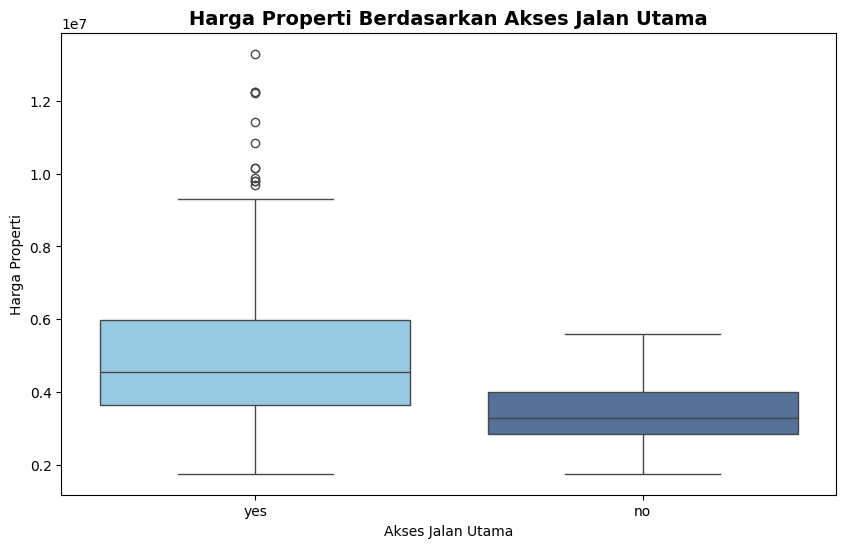

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='mainroad',
    y='price',
    hue='mainroad',
    palette=['#89CFF0','#4A6FA5'],
    legend=False
)

plt.title('Harga Properti Berdasarkan Akses Jalan Utama',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Akses Jalan Utama')
plt.ylabel('Harga Properti')

plt.show()

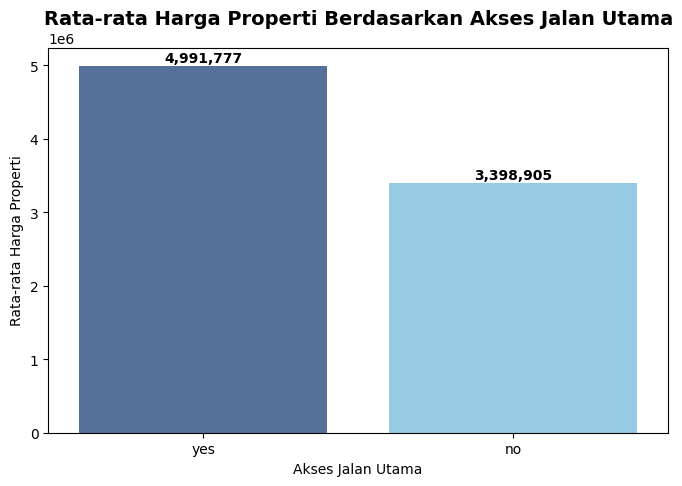

In [ ]:
avg_price = df.groupby('mainroad')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette=['#4A6FA5','#89CFF0']
)

for i, value in enumerate(avg_price.values):
    ax.text(
        i,
        value + 50000,
        f'{value:,.0f}',
        ha='center',
        fontweight='bold'
    )

plt.title('Rata-rata Harga Properti Berdasarkan Akses Jalan Utama',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Akses Jalan Utama')
plt.ylabel('Rata-rata Harga Properti')

plt.show()

In [ ]:
df.groupby('mainroad')['price'].mean().apply(lambda x: f"{x:,.0f}")

,price
mainroad,
no,"3,398,905"
yes,"4,991,777"


**Analisis :**

Berdasarkan visualisasi boxplot, properti yang memiliki akses ke jalan utama *(main road = yes)* memiliki median harga yang lebih tinggi dibandingkan properti yang tidak memiliki akses langsung ke jalan utama *(main road = no).*

Hasil perhitungan rata-rata harga juga menunjukkan perbedaan yang cukup signifikan. Properti yang berada di dekat jalan utama memiliki rata-rata harga sebesar 4.991.777, sedangkan properti yang tidak berada di dekat jalan utama memiliki rata-rata harga sebesar 3.398.905.

Temuan ini menunjukkan bahwa aksesibilitas merupakan salah satu faktor yang memengaruhi nilai properti. Rumah yang memiliki akses langsung ke jalan utama cenderung memiliki harga yang lebih tinggi dibandingkan rumah yang berada di area yang lebih jauh dari jalur utama.

**Insight Bisnis :**

Properti yang memiliki akses ke jalan utama memiliki harga rata-rata sekitar 46,9% lebih tinggi dibandingkan properti yang tidak memiliki akses langsung ke jalan utama.

Perhitungan:

**(4.991.777 − 3.398.905) : 3.398.905 × 100 ≈ 46,9%**

Artinya, akses jalan utama memberikan premium harga yang cukup besar terhadap nilai properti.

Bagi first-time home buyer, hasil ini menunjukkan bahwa kemudahan akses transportasi dan mobilitas memiliki konsekuensi terhadap peningkatan harga rumah. Oleh karena itu, calon pembeli perlu mempertimbangkan apakah manfaat akses jalan utama sebanding dengan tambahan biaya yang harus dikeluarkan. Jika memiliki keterbatasan anggaran, memilih rumah yang tidak berada tepat di jalur utama dapat menjadi alternatif untuk memperoleh harga yang lebih terjangkau.

## **7.6 Analisis Harga Properti Berdasarkan Jumlah Kamar Tidur**

**Tujuan Analisis** : Menganalisis pengaruh jumlah kamar tidur terhadap harga properti untuk mengetahui apakah penambahan jumlah kamar tidur berkontribusi terhadap peningkatan nilai jual rumah.

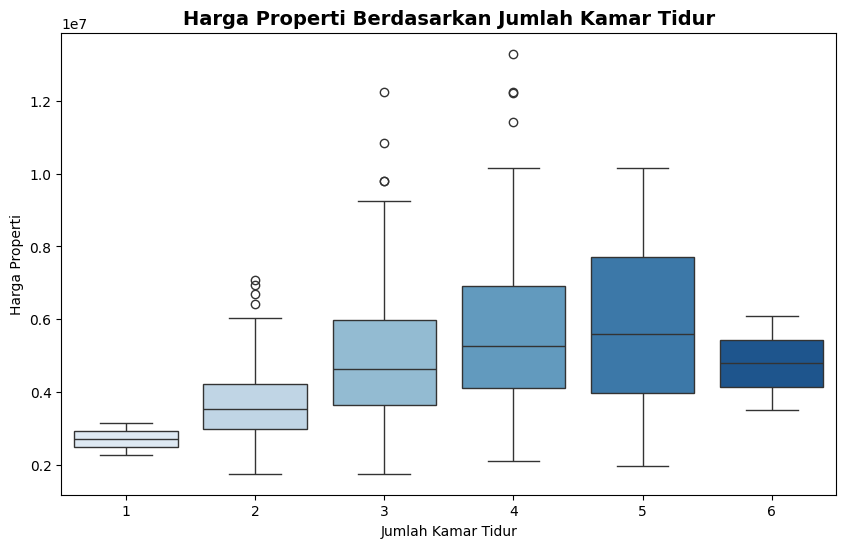

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='bedrooms',
    y='price',
    palette='Blues'
)

plt.title('Harga Properti Berdasarkan Jumlah Kamar Tidur',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Jumlah Kamar Tidur')
plt.ylabel('Harga Properti')

plt.show()

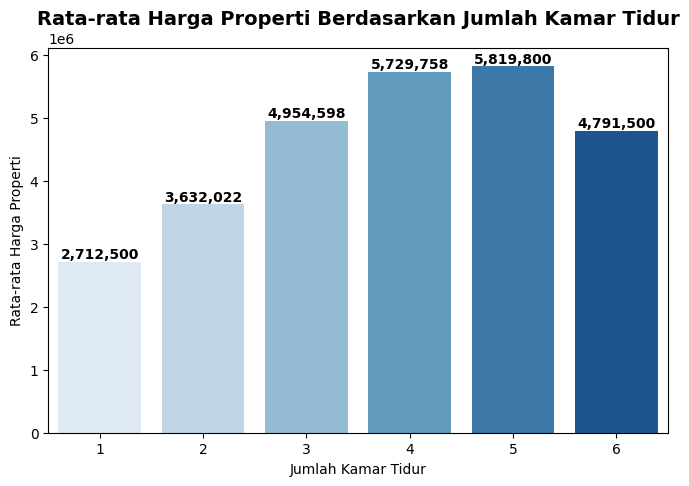

In [ ]:
avg_price = df.groupby('bedrooms')['price'].mean()

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette='Blues'
)

for i, value in enumerate(avg_price.values):
    ax.text(
        i,
        value + 50000,
        f'{value:,.0f}',
        ha='center',
        fontweight='bold'
    )

plt.title('Rata-rata Harga Properti Berdasarkan Jumlah Kamar Tidur',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Jumlah Kamar Tidur')
plt.ylabel('Rata-rata Harga Properti')

plt.show()

In [ ]:
df.groupby('bedrooms')['price'].mean().apply(lambda x: f"{x:,.0f}")

,price
bedrooms,
1,"2,712,500"
2,"3,632,022"
3,"4,954,598"
4,"5,729,758"
5,"5,819,800"
6,"4,791,500"


**Analisis :**

Berdasarkan visualisasi boxplot dan rata-rata harga properti, terlihat bahwa jumlah kamar tidur memiliki hubungan positif dengan harga rumah. Secara umum, rata-rata harga properti meningkat seiring bertambahnya jumlah kamar tidur.

Properti dengan 1 kamar tidur memiliki rata-rata harga sebesar 2.712.500, sedangkan properti dengan 5 kamar tidur memiliki rata-rata harga tertinggi sebesar 5.819.800. Hal ini menunjukkan bahwa rumah dengan kapasitas hunian yang lebih besar cenderung memiliki nilai jual yang lebih tinggi.

Namun, terdapat pola menarik pada rumah dengan 6 kamar tidur. Meskipun memiliki jumlah kamar lebih banyak dibandingkan rumah dengan 5 kamar tidur, rata-rata harganya justru lebih rendah, yaitu sebesar 4.791.500. Kondisi ini menunjukkan bahwa jumlah kamar tidur bukan satu-satunya faktor yang menentukan harga rumah. Faktor lain seperti lokasi, luas bangunan, akses jalan utama, dan fasilitas rumah juga berkontribusi terhadap nilai properti.

**Insight Bisnis :**

Jumlah kamar tidur merupakan salah satu faktor yang memengaruhi harga properti, terutama untuk rumah dengan kapasitas hunian yang lebih besar. Secara umum, penambahan kamar tidur diikuti oleh peningkatan harga rumah.

Bagi first-time home buyer, rumah dengan 3 hingga 4 kamar tidur dapat menjadi pilihan yang menarik karena menawarkan kapasitas hunian yang cukup untuk kebutuhan jangka panjang tanpa harus memasuki segmen rumah dengan harga tertinggi. Sebaliknya, rumah dengan jumlah kamar yang lebih banyak umumnya membutuhkan anggaran yang lebih besar dan lebih cocok untuk keluarga dengan kebutuhan ruang yang lebih tinggi.

## **7.7 Analisis Faktor-Faktor yang Mempengaruhi Harga Properti**

### **7.7.1 Persiapan Data untuk Analisis Korelasi**

**Tujuan :** Membuat salinan dataset untuk proses encoding sehingga data asli tetap terjaga.

In [ ]:
df_corr = df.copy()

### **7.7.2 Encoding Variabel Kategorikal Biner**

**Tujuan :** Mengubah variabel kategorikal dengan nilai yes/no menjadi bentuk numerik agar dapat digunakan dalam analisis korelasi.

In [ ]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df_corr[col] = df_corr[col].map({
        'yes':1,
        'no':0
    })

### **7.7.3 Encoding Variabel Furnishing Status**

**Tujuan :** Mengubah status furnishing menjadi nilai numerik agar dapat dihitung hubungan korelasinya dengan harga properti.

In [ ]:
df_corr['furnishingstatus'] = df_corr['furnishingstatus'].map({
    'unfurnished':0,
    'semi-furnished':1,
    'furnished':2
})

### **7.7.4 Analisis Korelasi Antar Variabel**

**Tujuan :** Mengidentifikasi hubungan antar variabel pada dataset serta melihat variabel yang memiliki hubungan dengan harga properti.

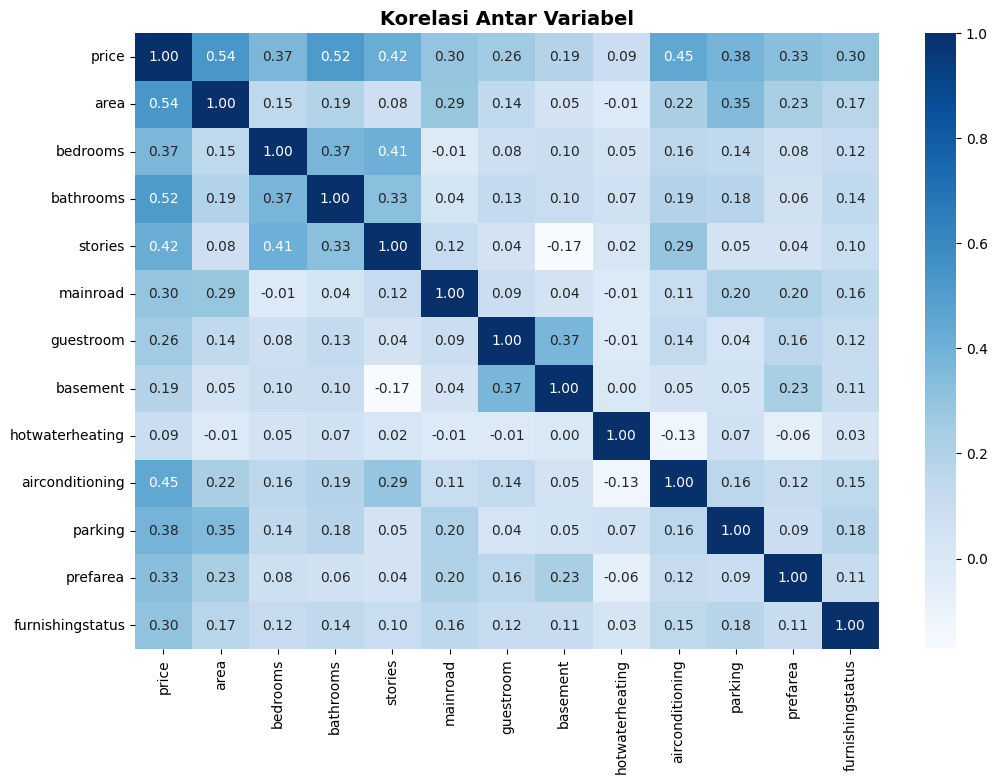

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_corr.corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title(
    'Korelasi Antar Variabel',
    fontsize=14,
    fontweight='bold'
)

plt.show()

### **7.7.5 Identifikasi Korelasi Variabel terhadap Harga Properti**

**Tujuan :** Mengetahui tingkat hubungan masing-masing variabel terhadap harga properti.

In [ ]:
corr_price = (
    df_corr.corr()['price']
    .sort_values(ascending=False)
)

corr_price

,price
price,1.000000
area,0.535997
bathrooms,0.517545
airconditioning,0.452954
stories,0.420712
parking,0.384394
bedrooms,0.366494
prefarea,0.329777
furnishingstatus,0.304721
mainroad,0.296898


### **7.7.6 Visualisasi Faktor-Faktor yang Mempengaruhi Harga Properti**

**Tujuan :** Memvisualisasikan ranking faktor yang memiliki hubungan dengan harga properti sehingga lebih mudah diinterpretasikan.

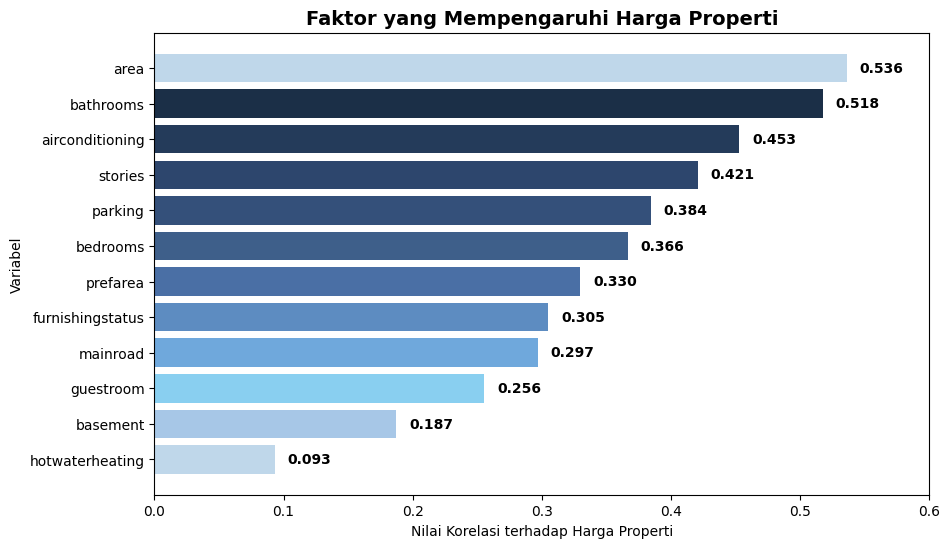

In [ ]:
corr_price = (
    df_corr.corr()['price']
    .drop('price')
    .sort_values(ascending=True)
)

plt.figure(figsize=(10,6))

colors = ['#BFD7EA','#A7C7E7','#89CFF0','#6FA8DC',
          '#5D8CC1','#4A6FA5','#3E5F8A',
          '#34507A','#2D466D','#243B5A','#1B2F47']

bars = plt.barh(
    corr_price.index,
    corr_price.values,
    color=colors
)

# Label nilai korelasi
for i, v in enumerate(corr_price.values):
    plt.text(
        v + 0.01,
        i,
        f'{v:.3f}',
        va='center',
        fontweight='bold'
    )

plt.title(
    'Faktor yang Mempengaruhi Harga Properti',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Nilai Korelasi terhadap Harga Properti')
plt.ylabel('Variabel')

plt.xlim(0, 0.6)

plt.show()

**Analisis :**

Berdasarkan hasil analisis korelasi, terdapat beberapa variabel yang menunjukkan hubungan positif terhadap harga properti. Variabel dengan nilai korelasi tertinggi adalah **luas properti (area) sebesar 0,536, diikuti oleh jumlah kamar mandi (bathrooms) sebesar 0,518, air conditioning sebesar 0,453, dan jumlah lantai (stories) sebesar 0,421.**

Hasil ini menunjukkan bahwa semakin luas properti dan semakin lengkap fasilitas yang dimiliki, maka harga properti cenderung meningkat. Selain itu, faktor kenyamanan seperti keberadaan air conditioning juga memiliki hubungan yang cukup kuat terhadap harga rumah.

Sebaliknya, variabel seperti **hot water heating (0,093) dan basement (0,187) **menunjukkan hubungan yang relatif lemah terhadap harga properti. Hal ini mengindikasikan bahwa kedua fitur tersebut bukan merupakan faktor utama yang menentukan nilai jual rumah pada dataset ini.

**Insight Bisnis :**

Bagi first-time home buyer, hasil analisis menunjukkan bahwa luas properti, jumlah kamar mandi, dan fasilitas rumah merupakan faktor yang paling memengaruhi harga rumah.

Menariknya, jumlah kamar mandi memiliki korelasi yang lebih tinggi dibandingkan jumlah kamar tidur. Hal ini menunjukkan bahwa peningkatan kenyamanan dan fungsi rumah dapat memberikan pengaruh yang lebih besar terhadap harga dibandingkan sekadar penambahan jumlah kamar.

Selain itu, faktor lokasi seperti preferred area dan akses jalan utama juga menunjukkan hubungan positif terhadap harga properti, yang mengindikasikan bahwa rumah di lokasi yang lebih strategis umumnya memiliki harga yang lebih tinggi.

## **7.8 Ringkasan Temuan EDA**

**Tujuan Analisis :** Merangkum temuan utama dari hasil exploratory data analysis (EDA) untuk mengidentifikasi faktor-faktor yang memengaruhi harga properti serta implikasinya bagi first-time home buyer.


---



**Ringkasan Temuan :** Berdasarkan hasil exploratory data analysis yang telah dilakukan, ditemukan beberapa faktor yang memiliki pengaruh terhadap harga properti.

Distribusi harga properti menunjukkan bahwa sebagian besar rumah berada pada segmen harga menengah, dengan rata-rata harga sebesar 4.766.729 dan median sebesar 4.340.000. Hal ini menunjukkan bahwa pasar perumahan pada dataset didominasi oleh properti dengan harga yang relatif terjangkau dibandingkan segmen premium.

Analisis hubungan antara luas properti dan harga rumah menunjukkan adanya hubungan positif, di mana peningkatan luas properti cenderung diikuti oleh kenaikan harga rumah.

Dari sisi fasilitas, properti dengan status furnished memiliki rata-rata harga tertinggi sebesar 5.495.696, diikuti oleh semi-furnished sebesar 4.907.524, dan unfurnished sebesar 4.013.831. Hal ini menunjukkan bahwa kelengkapan furnitur memberikan nilai tambah terhadap harga properti.

Faktor lokasi juga menunjukkan pengaruh yang cukup signifikan. Properti yang berada di preferred area memiliki rata-rata harga sekitar 32,9% lebih tinggi dibandingkan properti di area non-preferred. Selain itu, properti yang memiliki akses ke jalan utama memiliki rata-rata harga sekitar 46,9% lebih tinggi dibandingkan properti yang tidak memiliki akses langsung ke jalan utama.

Berdasarkan analisis korelasi, faktor yang memiliki hubungan paling kuat terhadap harga properti adalah luas properti (0,536), jumlah kamar mandi (0,518), air conditioning (0,453), dan jumlah lantai (0,421).


---



**Implikasi bagi First-Time Home Buyer :** Hasil analisis menunjukkan bahwa keputusan pembelian rumah tidak hanya dipengaruhi oleh harga, tetapi juga oleh karakteristik properti seperti luas bangunan, jumlah kamar mandi, lokasi, aksesibilitas, dan fasilitas yang tersedia.

Bagi first-time home buyer, memahami faktor-faktor tersebut dapat membantu dalam menentukan prioritas kebutuhan serta menyesuaikan pilihan rumah dengan anggaran yang dimiliki. Properti dengan lokasi strategis dan fasilitas yang lebih lengkap cenderung memiliki harga yang lebih tinggi, sehingga calon pembeli perlu mempertimbangkan trade-off antara kenyamanan, lokasi, dan keterjangkauan harga sebelum mengambil keputusan pembelian.

# **8. Data Preprocessing**



## **8.1 Persiapan Data untuk Modeling**

**Tujuan :** Menyiapkan dataset yang akan digunakan pada tahap pemodelan dengan membuat salinan data agar dataset asli tetap terjaga.

In [ ]:
df_model = df.copy()

## **8.2 Encoding Variabel Kategorikal**

**Tujuan :** Mengubah variabel kategorikal menjadi format numerik agar dapat diproses oleh algoritma machine learning.

**Binary Encoding**

In [ ]:
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_cols:
    df_model[col] = df_model[col].map({
        'yes':1,
        'no':0
    })

**One Hot Encoding Furnishing Status**

In [ ]:
df_model = pd.get_dummies(
    df_model,
    columns=['furnishingstatus'],
    drop_first=True
)

df_model.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [ ]:
df_model.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

In [ ]:
dummy_cols = [
    'furnishingstatus_semi-furnished',
    'furnishingstatus_unfurnished'
]

df_model[dummy_cols] = df_model[dummy_cols].astype(int)

df_model.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## **8.3 Feature Selection dan Target Selection**

**Tujuan :** Memisahkan variabel input (feature) dan variabel target yang akan diprediksi.

**Feature (X)**

In [ ]:
X = df_model.drop('price', axis=1)

**Target (y)**

In [ ]:
y = df_model['price']

**Check Shape**

In [ ]:
print("Shape X :", X.shape)
print("Shape y :", y.shape)

Shape X : (545, 13)
Shape y : (545,)


## **8.4 Train-Test Split**

**Tujuan :** Membagi dataset menjadi data pelatihan dan data pengujian agar model dapat dievaluasi pada data yang belum pernah dilihat sebelumnya.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Check Ukuran Data**

In [ ]:
print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)
print("y Train :", y_train.shape)
print("y Test  :", y_test.shape)

X Train : (436, 13)
X Test  : (109, 13)
y Train : (436,)
y Test  : (109,)


## **8.5 Feature Scaling**

**Tujuan :** Menyeragamkan skala antar fitur sehingga model dapat bekerja lebih optimal.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled[:5]

array([[ 0.38416819,  0.05527092,  1.53917323,  2.58764353,  0.40715525,
        -0.46677307, -0.74642003, -0.23052136,  1.50124327,  0.36795665,
        -0.55262032, -0.870669  , -0.67690027],
       [ 0.9291807 ,  0.05527092,  1.53917323, -0.91249891,  0.40715525,
        -0.46677307,  1.33972825, -0.23052136,  1.50124327,  2.70998729,
        -0.55262032,  1.14854209, -0.67690027],
       [-0.60775457, -1.28351359, -0.5579503 , -0.91249891,  0.40715525,
        -0.46677307,  1.33972825, -0.23052136,  1.50124327,  1.53897197,
        -0.55262032, -0.870669  , -0.67690027],
       [-1.15549214,  0.05527092, -0.5579503 ,  0.25421524,  0.40715525,
        -0.46677307,  1.33972825, -0.23052136, -0.66611456, -0.80305867,
         1.80956067, -0.870669  ,  1.47732249],
       [-0.63773026,  0.05527092, -0.5579503 ,  0.25421524,  0.40715525,
        -0.46677307, -0.74642003, -0.23052136, -0.66611456, -0.80305867,
        -0.55262032, -0.870669  ,  1.47732249]])

# **9. Modeling**



## **9.1 Linear Regression**

**Tujuan :** Membangun model baseline untuk memprediksi harga properti berdasarkan karakteristik rumah yang tersedia pada dataset.

**Training Model**

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

LinearRegression()

**Prediksi**

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)

**Evaluasi**

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("R²   :", round(r2_lr,4))
print("MAE  :", round(mae_lr,2))
print("RMSE :", round(rmse_lr,2))

R²   : 0.6529
MAE  : 970043.4
RMSE : 1324506.96


In [ ]:
lr_metrics = pd.DataFrame({
    'Metric':['R² Score','MAE','RMSE'],
    'Value':[
        '0.6529',
        f"{mae_lr:,.0f}",
        f"{rmse_lr:,.0f}"
    ]
})

lr_metrics

,Metric,Value
0,R² Score,0.6529
1,MAE,"970,043"
2,RMSE,"1,324,507"


**Analisis Nilai R²**

Model Linear Regression menghasilkan nilai R² sebesar 0,6529, yang menunjukkan bahwa model mampu menjelaskan sekitar 65,29% variasi harga properti berdasarkan variabel-variabel yang digunakan dalam penelitian. Hasil ini mengindikasikan bahwa model memiliki kemampuan yang cukup baik dalam menangkap hubungan antara karakteristik properti dan harga rumah. Namun, masih terdapat sekitar 34,71% variasi harga properti yang dipengaruhi oleh faktor lain di luar variabel yang digunakan dalam model.

**Analisis Nilai MAE**

Model menghasilkan nilai Mean Absolute Error (MAE) sebesar 970.043. Nilai ini menunjukkan bahwa rata-rata selisih antara harga properti yang diprediksi model dengan harga aktual adalah sekitar 970 ribu satuan harga. Semakin kecil nilai MAE, semakin baik kemampuan model dalam melakukan prediksi. Hasil ini menunjukkan bahwa model mampu memberikan estimasi harga properti yang cukup mendekati nilai aktual, meskipun masih terdapat perbedaan pada beberapa observasi.

**Analisis Nilai RMSE**

Model menghasilkan nilai Root Mean Squared Error (RMSE) sebesar 1.324.507. Nilai RMSE yang lebih besar dibandingkan MAE menunjukkan adanya beberapa prediksi yang memiliki kesalahan cukup besar. Hal ini disebabkan karena RMSE memberikan penalti yang lebih tinggi terhadap error yang besar. Dengan demikian, meskipun secara umum model mampu memprediksi harga properti dengan cukup baik, masih terdapat beberapa properti yang sulit diprediksi secara akurat oleh model.

**Visualisasi Actual vs Predicted**

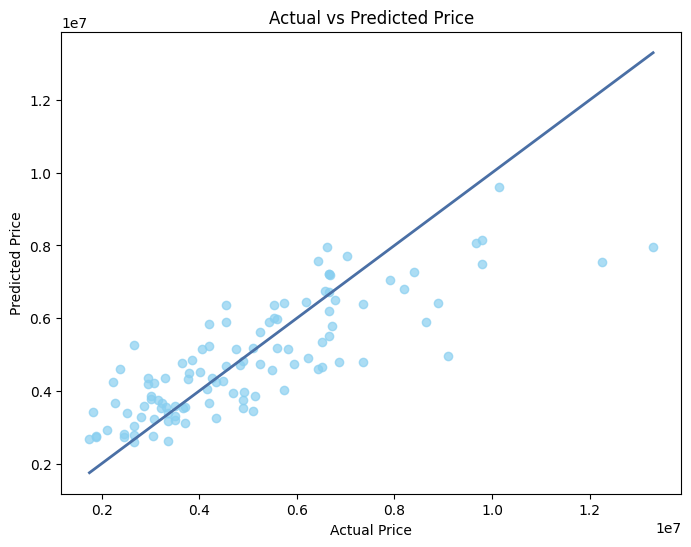

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_lr,
    color='#89CFF0',
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#4A6FA5',
    linewidth=2
)

plt.title('Actual vs Predicted Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.show()

**Analisis Visualisasi Actual vs Predicted**

Grafik menunjukkan bahwa sebagian besar titik mengikuti arah garis diagonal, yang menandakan bahwa model berhasil menangkap hubungan umum antara karakteristik rumah dan harga properti.

Namun terdapat beberapa titik yang cukup jauh dari garis diagonal, terutama pada properti dengan harga yang lebih tinggi. Hal ini menunjukkan bahwa model masih mengalami kesulitan dalam memprediksi beberapa rumah dengan karakteristik tertentu secara akurat.

Secara keseluruhan, model Linear Regression mampu memberikan prediksi yang cukup baik, tetapi masih terdapat ruang untuk peningkatan performa melalui metode regularisasi seperti Ridge Regression dan Lasso Regression.

**Insight Bisnis**

Bagi first-time home buyer, model Linear Regression sudah mampu memberikan estimasi harga yang cukup representatif berdasarkan karakteristik rumah. Namun karena rata-rata kesalahan prediksi masih mendekati 1 juta, hasil prediksi sebaiknya digunakan sebagai referensi awal dan bukan sebagai satu-satunya dasar dalam menentukan keputusan pembelian properti.

## **9.2 Ridge Regression**

**Tujuan :** Mengurangi dampak multikolinearitas dengan memberikan regularisasi pada model regresi.

**Training Model**

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train_scaled, y_train)

Ridge()

**Prediksi**

In [ ]:
y_pred_ridge = ridge.predict(X_test_scaled)

**Evaluasi**

In [ ]:
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("R²   :", round(r2_ridge,4))
print("MAE  :", round(mae_ridge,2))
print("RMSE :", round(rmse_ridge,2))

R²   : 0.6528
MAE  : 969857.9
RMSE : 1324703.49


In [ ]:
ridge_metrics = pd.DataFrame({
    'Metric':['R² Score','MAE','RMSE'],
    'Value':[
        '0.6528',
        f"{mae_ridge:,.0f}",
        f"{rmse_ridge:,.0f}"
    ]
})

ridge_metrics

,Metric,Value
0,R² Score,0.6528
1,MAE,"969,858"
2,RMSE,"1,324,703"


**Analisis Nilai R²**

Model Ridge Regression menghasilkan nilai R² sebesar 0,6528, yang menunjukkan bahwa model mampu menjelaskan sekitar 65,28% variasi harga properti berdasarkan variabel yang digunakan. Nilai ini hampir sama dengan model Linear Regression, sehingga regularisasi yang diterapkan belum memberikan peningkatan yang signifikan terhadap kemampuan model dalam menjelaskan variasi harga properti.

**Analisis Nilai MAE**

Model menghasilkan nilai Mean Absolute Error (MAE) sebesar 969.858. Nilai ini menunjukkan bahwa rata-rata selisih antara harga prediksi dan harga aktual berada pada kisaran 969 ribu satuan harga. Dibandingkan dengan Linear Regression, nilai MAE sedikit lebih rendah, yang menunjukkan adanya perbaikan kecil pada tingkat kesalahan rata-rata prediksi.

**Analisis Nilai RMSE**

Model menghasilkan nilai Root Mean Squared Error (RMSE) sebesar 1.324.703. Nilai ini sedikit lebih tinggi dibandingkan Linear Regression, yang menunjukkan bahwa masih terdapat beberapa prediksi dengan kesalahan yang relatif besar. Dengan demikian, penerapan regularisasi Ridge belum mampu mengurangi error besar secara signifikan pada dataset ini.

**Visualisasi Actual vs Predicted**

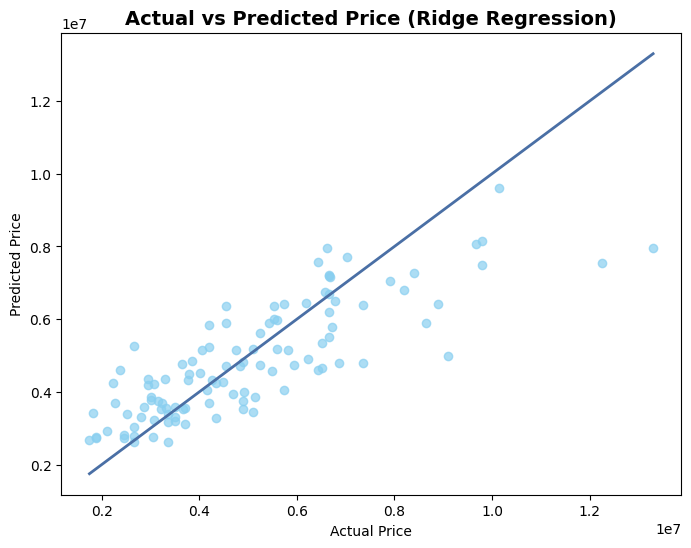

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_ridge,
    color='#89CFF0',
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#4A6FA5',
    linewidth=2
)

plt.title('Actual vs Predicted Price (Ridge Regression)',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.show()

**Analisis Visualisasi Actual vs Predicted**

Berdasarkan visualisasi Actual vs Predicted, sebagian besar titik data berada di sekitar garis diagonal yang merepresentasikan kondisi prediksi sempurna. Hal ini menunjukkan bahwa model Ridge Regression mampu menangkap pola hubungan antara karakteristik properti dan harga rumah dengan cukup baik.

Namun, masih terdapat beberapa titik yang berada cukup jauh dari garis diagonal, terutama pada properti dengan harga yang lebih tinggi. Kondisi ini menunjukkan bahwa model masih mengalami kesalahan prediksi pada beberapa observasi tertentu, khususnya pada segmen properti dengan harga tinggi.

Selain itu, pola penyebaran titik pada model Ridge Regression terlihat sangat mirip dengan model Linear Regression. Temuan ini sejalan dengan hasil evaluasi yang menunjukkan bahwa nilai R², MAE, dan RMSE kedua model memiliki perbedaan yang sangat kecil.

**Insight Bisnis**

Hasil prediksi menggunakan model Ridge Regression menunjukkan bahwa model mampu memperkirakan harga properti dengan cukup baik berdasarkan karakteristik rumah yang tersedia pada dataset. Dengan nilai R² sebesar 65,28%, model telah mampu menangkap sebagian besar faktor yang memengaruhi harga properti.

Bagi first-time home buyer, model ini dapat dimanfaatkan sebagai alat bantu untuk memperkirakan harga wajar suatu rumah berdasarkan karakteristik seperti luas bangunan, jumlah kamar mandi, jumlah lantai, lokasi, dan fasilitas yang tersedia. Dengan adanya estimasi harga tersebut, calon pembeli dapat memperoleh gambaran awal mengenai nilai properti sebelum melakukan negosiasi atau pengambilan keputusan pembelian.

Selain itu, hasil evaluasi menunjukkan bahwa masih terdapat selisih antara harga aktual dan harga prediksi. Oleh karena itu, hasil prediksi sebaiknya digunakan sebagai referensi pendukung, bukan sebagai satu-satunya dasar dalam menentukan keputusan pembelian rumah. Faktor lain seperti kondisi lingkungan, akses transportasi, keamanan, dan preferensi pribadi tetap perlu dipertimbangkan oleh calon pembeli.

## **9.3 Lasso Regression**

**Tujuan :** Melakukan regularisasi sekaligus seleksi fitur untuk mengidentifikasi variabel yang paling relevan terhadap harga properti.

**Training Model**

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.1)

**Prediksi**

In [ ]:
y_pred_lasso = lasso.predict(X_test_scaled)

**Evaluasi**

In [ ]:
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("R²   :", round(r2_lasso,4))
print("MAE  :", round(mae_lasso,2))
print("RMSE :", round(rmse_lasso,2))

R²   : 0.6529
MAE  : 970043.4
RMSE : 1324507.01


In [ ]:
lasso_metrics = pd.DataFrame({
    'Metric':['R² Score','MAE','RMSE'],
    'Value':[
        '0.6529',
        f"{mae_lasso:,.0f}",
        f"{rmse_lasso:,.0f}"
    ]
})

lasso_metrics

,Metric,Value
0,R² Score,0.6529
1,MAE,"970,043"
2,RMSE,"1,324,507"


**Analisis Nilai R²**

Model Lasso Regression menghasilkan nilai R² sebesar 0,6529, yang menunjukkan bahwa model mampu menjelaskan sekitar 65,29% variasi harga properti berdasarkan variabel yang digunakan dalam penelitian. Nilai ini identik dengan model Linear Regression, sehingga kemampuan model dalam menjelaskan variasi harga properti dapat dikatakan relatif sama.

**Analisis Nilai MAE**

Model menghasilkan nilai Mean Absolute Error (MAE) sebesar 970.043. Nilai tersebut menunjukkan bahwa rata-rata selisih antara harga prediksi dan harga aktual berada pada kisaran 970 ribu satuan harga. Hasil ini menunjukkan bahwa tingkat kesalahan prediksi model masih berada pada rentang yang sama dengan model Linear Regression.

**Analisis Nilai RMSE**

Model menghasilkan nilai Root Mean Squared Error (RMSE) sebesar 1.324.507. Nilai ini menunjukkan bahwa masih terdapat beberapa prediksi dengan kesalahan yang cukup besar. Namun, secara keseluruhan performa model masih tergolong baik dalam memprediksi harga properti berdasarkan karakteristik rumah yang tersedia.

**Visualisasi Actual vs Predicted**

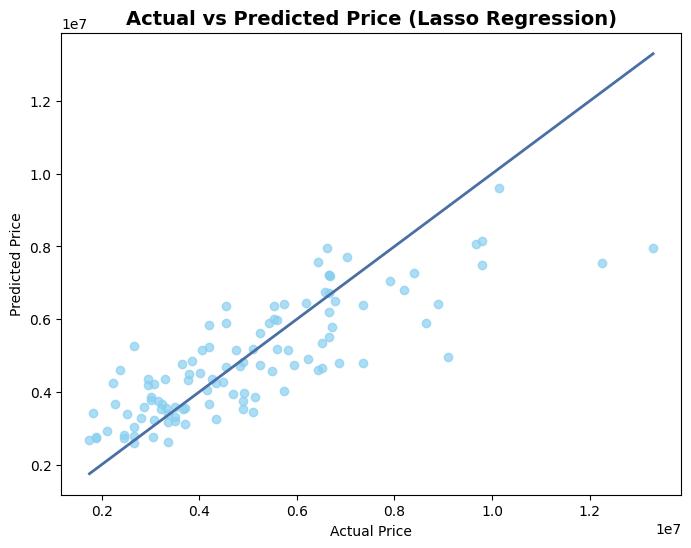

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_lasso,
    color='#89CFF0',
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='#4A6FA5',
    linewidth=2
)

plt.title(
    'Actual vs Predicted Price (Lasso Regression)',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.show()

**Analisis Visualisasi**

Berdasarkan visualisasi Actual vs Predicted, sebagian besar titik data berada di sekitar garis diagonal yang merepresentasikan kondisi prediksi ideal. Hal ini menunjukkan bahwa model Lasso Regression mampu menangkap pola hubungan antara karakteristik properti dan harga rumah dengan cukup baik.

Namun, masih terdapat beberapa titik yang berada cukup jauh dari garis diagonal, terutama pada properti dengan harga yang lebih tinggi. Kondisi ini menunjukkan bahwa model masih mengalami kesalahan prediksi pada beberapa observasi tertentu, khususnya pada segmen properti dengan harga tinggi.

Pola penyebaran titik pada model Lasso Regression terlihat sangat mirip dengan model Linear Regression dan Ridge Regression. Temuan ini sejalan dengan hasil evaluasi yang menunjukkan bahwa nilai R², MAE, dan RMSE ketiga model memiliki perbedaan yang sangat kecil. Dengan demikian, penerapan regularisasi Lasso belum memberikan peningkatan performa yang signifikan pada dataset ini.

**Insight Bisnis**

Model Lasso Regression mampu memberikan estimasi harga properti yang cukup representatif berdasarkan karakteristik rumah yang tersedia pada dataset. Hasil prediksi dapat dimanfaatkan oleh first-time home buyer untuk memperoleh gambaran harga wajar suatu properti sebelum melakukan pembelian.

Meskipun demikian, hasil prediksi masih memiliki tingkat kesalahan tertentu sehingga sebaiknya digunakan sebagai alat bantu pengambilan keputusan, bukan sebagai satu-satunya dasar dalam menentukan pilihan rumah. Faktor lain seperti kondisi lingkungan, akses transportasi, keamanan, serta preferensi pribadi tetap perlu dipertimbangkan dalam proses pembelian properti.

# **10. Perbandingan Performa Model**

In [ ]:
comparison_display = comparison.copy()

comparison_display['R2'] = comparison_display['R2'].round(4)
comparison_display['MAE'] = comparison_display['MAE'].apply(lambda x: f"{x:,.0f}")
comparison_display['RMSE'] = comparison_display['RMSE'].apply(lambda x: f"{x:,.0f}")

comparison_display

,Model,R2,MAE,RMSE
0,Linear Regression,0.6529,"970,043","1,324,507"
1,Ridge Regression,0.6528,"969,858","1,324,703"
2,Lasso Regression,0.6529,"970,043","1,324,507"


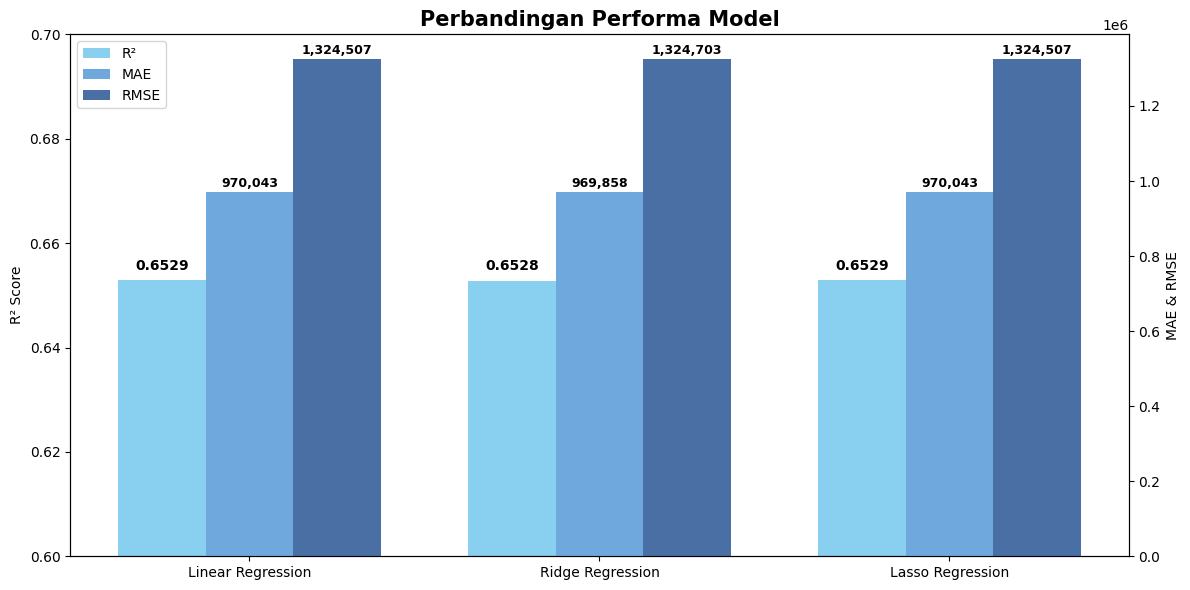

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = comparison['Model']

r2 = comparison['R2']
mae = comparison['MAE']
rmse = comparison['RMSE']

x = np.arange(len(models))
width = 0.25

fig, ax1 = plt.subplots(figsize=(12,6))

# Sumbu kiri untuk R²
bars1 = ax1.bar(
    x - width,
    r2,
    width,
    label='R²',
    color='#89CFF0'
)

ax1.set_ylabel('R² Score')
ax1.set_ylim(0.60, 0.70)

# Label R²
for bar in bars1:
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.002,
        f'{bar.get_height():.4f}',
        ha='center',
        fontweight='bold'
    )

# Sumbu kanan untuk MAE dan RMSE
ax2 = ax1.twinx()

bars2 = ax2.bar(
    x,
    mae,
    width,
    label='MAE',
    color='#6FA8DC'
)

bars3 = ax2.bar(
    x + width,
    rmse,
    width,
    label='RMSE',
    color='#4A6FA5'
)

# Label MAE
for bar in bars2:
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 15000,
        f'{bar.get_height():,.0f}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

# Label RMSE
for bar in bars3:
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 15000,
        f'{bar.get_height():,.0f}',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

ax1.set_xticks(x)
ax1.set_xticklabels(models)

ax2.set_ylabel('MAE & RMSE')

plt.title(
    'Perbandingan Performa Model',
    fontsize=15,
    fontweight='bold'
)

# Gabung legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()

ax1.legend(
    h1 + h2,
    l1 + l2,
    loc='upper left'
)

plt.tight_layout()
plt.show()

**Analisis Perbandingan Performa Model**

Berdasarkan hasil evaluasi yang ditampilkan pada grafik perbandingan performa model, ketiga model regresi yang digunakan yaitu Linear Regression, Ridge Regression, dan Lasso Regression menghasilkan performa yang hampir identik dalam memprediksi harga properti.

Dari sisi R² Score, Linear Regression dan Lasso Regression memperoleh nilai sebesar 0,6529, sedangkan Ridge Regression memperoleh nilai 0,6528. Perbedaan tersebut sangat kecil sehingga kemampuan ketiga model dalam menjelaskan variasi harga properti dapat dianggap setara. Hal ini menunjukkan bahwa sekitar 65% variasi harga properti dapat dijelaskan oleh variabel-variabel yang digunakan dalam penelitian.

Jika dilihat dari nilai Mean Absolute Error (MAE), Ridge Regression menghasilkan nilai error paling rendah yaitu 969.858, sedangkan Linear Regression dan Lasso Regression memiliki nilai MAE sebesar 970.043. Meskipun Ridge Regression menunjukkan hasil terbaik pada metrik ini, selisihnya sangat kecil sehingga tidak memberikan peningkatan performa yang signifikan.

Hal serupa juga terlihat pada nilai Root Mean Squared Error (RMSE). Linear Regression dan Lasso Regression menghasilkan nilai RMSE sebesar 1.324.507, sedangkan Ridge Regression menghasilkan nilai RMSE sebesar 1.324.703. Perbedaan tersebut relatif kecil sehingga ketiga model memiliki tingkat kesalahan prediksi yang hampir sama.

Secara keseluruhan, hasil evaluasi menunjukkan bahwa penerapan regularisasi pada Ridge Regression dan Lasso Regression belum mampu meningkatkan performa model secara signifikan dibandingkan Linear Regression pada dataset ini.'



---

**Insight Bisnis**

Bagi first-time home buyer, hasil penelitian menunjukkan bahwa model prediksi harga properti yang dibangun telah mampu memberikan estimasi harga yang cukup baik dengan tingkat akurasi yang relatif serupa pada ketiga metode yang digunakan.

Karena seluruh model menghasilkan performa yang hampir sama, maka prediksi harga properti dapat dilakukan menggunakan model yang lebih sederhana yaitu Linear Regression tanpa kehilangan performa yang berarti. Hal ini memberikan keuntungan dari sisi interpretasi model karena hubungan antara karakteristik rumah dan harga properti menjadi lebih mudah dipahami.

Selain itu, hasil analisis menunjukkan bahwa faktor-faktor seperti luas properti, jumlah kamar mandi, jumlah lantai, lokasi, dan fasilitas rumah merupakan aspek yang paling memengaruhi harga properti. Oleh karena itu, first-time home buyer dapat memanfaatkan informasi tersebut untuk menentukan prioritas ketika memilih rumah sesuai dengan kebutuhan dan anggaran yang dimiliki.



---

**Model Terbaik**

Berdasarkan hasil evaluasi, Linear Regression dipilih sebagai model terbaik karena memiliki nilai R² tertinggi (bersama Lasso Regression), nilai RMSE terendah (bersama Lasso Regression), serta memiliki struktur model yang lebih sederhana dan mudah diinterpretasikan dibandingkan model regularisasi.


# **11. Kesimpulan**

Penelitian ini bertujuan untuk menganalisis faktor-faktor yang memengaruhi harga properti serta membangun model prediksi harga rumah untuk mendukung pengambilan keputusan pembelian rumah bagi first-time home buyer. Berdasarkan hasil exploratory data analysis (EDA), ditemukan bahwa beberapa faktor memiliki hubungan positif terhadap harga properti, di antaranya luas properti (area), jumlah kamar mandi (bathrooms), keberadaan air conditioning, jumlah lantai (stories), lokasi pada preferred area, serta akses ke jalan utama (main road).

Hasil analisis menunjukkan bahwa luas properti merupakan faktor yang memiliki hubungan paling kuat terhadap harga rumah dengan nilai korelasi sebesar 0,536, diikuti oleh jumlah kamar mandi sebesar 0,518 dan air conditioning sebesar 0,453. Temuan ini menunjukkan bahwa ukuran properti dan fasilitas yang tersedia menjadi pertimbangan utama dalam menentukan nilai jual sebuah rumah.

Pada tahap pemodelan, digunakan tiga metode regresi yaitu Linear Regression, Ridge Regression, dan Lasso Regression untuk memprediksi harga properti. Hasil evaluasi menunjukkan bahwa ketiga model memiliki performa yang hampir identik. Linear Regression dan Lasso Regression menghasilkan nilai R² sebesar 0,6529, sedangkan Ridge Regression menghasilkan nilai R² sebesar 0,6528. Selain itu, nilai MAE dan RMSE dari ketiga model juga menunjukkan perbedaan yang sangat kecil.

Berdasarkan hasil perbandingan model, Linear Regression dipilih sebagai model terbaik karena menghasilkan performa yang setara dengan Ridge Regression dan Lasso Regression, namun memiliki struktur yang lebih sederhana serta lebih mudah diinterpretasikan. Model ini mampu menjelaskan sekitar 65,29% variasi harga properti berdasarkan karakteristik rumah yang tersedia pada dataset.

Secara keseluruhan, hasil penelitian menunjukkan bahwa model prediksi yang dibangun dapat digunakan sebagai alat bantu untuk memperkirakan harga properti berdasarkan karakteristik rumah. Bagi first-time home buyer, hasil prediksi ini dapat dimanfaatkan sebagai referensi awal untuk menilai kewajaran harga rumah dan membandingkan beberapa alternatif properti sebelum melakukan keputusan pembelian. Namun demikian, keputusan pembelian tetap perlu mempertimbangkan faktor lain di luar dataset, seperti kondisi lingkungan, akses transportasi, keamanan, serta preferensi pribadi calon pembeli.

# **12. Rekomendasi**

Bagi first-time home buyer, faktor seperti luas properti, jumlah kamar mandi, lokasi, dan fasilitas rumah perlu menjadi prioritas utama dalam mempertimbangkan pembelian rumah karena terbukti memiliki pengaruh yang cukup besar terhadap harga properti. Selain itu, hasil prediksi model dapat digunakan sebagai alat bantu untuk membandingkan nilai beberapa properti sehingga calon pembeli dapat memilih rumah yang sesuai dengan kebutuhan dan kemampuan finansial.

Untuk pengembangan penelitian selanjutnya, dapat digunakan dataset dengan jumlah observasi yang lebih besar serta menambahkan variabel lain seperti usia bangunan, jarak ke pusat kota, akses transportasi umum, tingkat keamanan lingkungan, dan fasilitas pendidikan di sekitar properti. Selain itu, penelitian selanjutnya dapat mengimplementasikan metode yang lebih kompleks seperti Random Forest Regression, XGBoost Regression, atau Gradient Boosting Regression untuk meningkatkan akurasi prediksi harga properti.